# SBI Financial Report Intelligence System — Production V1 (local Jupyter)

**Source:** SBI Annual Report 2023-24  
**LLM:** Ollama `phi3` (local) · **Embeddings:** `all-MiniLM-L6-v2` (local) · **No cloud APIs**

Python is the source of truth for every number. `phi3` only rephrases an answer Python has already computed, and its output is rejected if it contains a number that Python did not produce.

## How to run (Windows / Mac / Linux, plain Jupyter)
1. Install **Ollama** from https://ollama.com/download (one time). Nothing else to do for it: the notebook starts it and pulls `phi3` for you.
2. Open this notebook in Jupyter / JupyterLab / VS Code / PyCharm.
3. In cell **00**, check `SOURCE_PDF` points to your annual report PDF.
4. Run cells top to bottom. The first run is slow (table extraction on 486 pages and model downloads). Everything slow is **cached** in `sbi_financial_ai/`, so re-runs take seconds.

**Slow laptop?** Set `EXTRACT_TABLES = False` and `USE_LLM = False` in cell 00. The system still answers every question correctly from the structured data, because it does not need the table extraction or the LLM.

## Architecture
```text
Annual Report PDF
   ├── page text / images / tables  (cached to disk)
   ├── Page 204 parsers: asset-quality ratios + sector-wise advances (checked against known report values)
   └── master_financial_data  (structured, validated)
            ├── query understanding  (type, metric, period, sector)
            ├── deterministic answer engine  (fact · comparison · ranking · calculation)
            └── hybrid retrieval (keyword + semantic) → supporting evidence
                         ↓
                 phi3 rephrases the deterministic answer
                         ↓
            number guard: reject any number Python did not produce
                         ↓
                 answer + PDF page + calculation
```

## 00 — Configuration

In [1]:
# 00 — Configuration (local Jupyter)
import os, re, json, math, time, shutil, warnings, subprocess, sys
from pathlib import Path

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

# ============================ EDIT THESE ============================
SOURCE_PDF = Path(r"C:\Users\Ansh\Desktop\SBI LLM\Data\AR_24037_SBIN_2023_2024_27052024232418.pdf")

EXTRACT_TABLES = True        # slow on 486 pages (cached after the first run). False = skip, the answers do not need it
TABLE_PAGES = None           # None = all pages. Or e.g. range(195, 215) for a quick test
EXTRACT_IMAGES = True        # embedded images, each distinct image saved once
USE_LLM = True               # False = deterministic answers only (fast, no Ollama needed)
RUN_LLM_EVALUATION = False   # True = also score phi3 answers in the evaluation section (slow)
REBUILD = False              # True = ignore the caches and redo extraction
# ====================================================================

PROJECT_NAME = "SBI Financial Report Intelligence System"
COMPANY = "State Bank of India"
REPORT_NAME = "Annual Report 2023-24"
REPORT_YEAR, PREVIOUS_YEAR = "FY2024", "FY2023"
OLLAMA_MODEL = "phi3"
EMBEDDING_MODEL = "all-MiniLM-L6-v2"
TOP_K = 6
KEY_PAGE = 204               # PDF page holding the asset-quality ratios and the sector-wise advances table

BASE_DIR = Path.cwd() / "sbi_financial_ai"
EXTRACTED_DIR = BASE_DIR / "extracted"
IMAGE_DIR = EXTRACTED_DIR / "images"
PAGE_DIR = EXTRACTED_DIR / "rendered_pages"
ARTIFACT_DIR = BASE_DIR / "artifacts"
for d in [BASE_DIR, EXTRACTED_DIR, IMAGE_DIR, PAGE_DIR, ARTIFACT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(PROJECT_NAME)
print("Working folder :", BASE_DIR)
print("PDF            :", SOURCE_PDF, "| found:", SOURCE_PDF.exists())

SBI Financial Report Intelligence System
Working folder : C:\Users\Ansh\Desktop\SBI LLM\sbi_financial_ai
PDF            : C:\Users\Ansh\Desktop\SBI LLM\Data\AR_24037_SBIN_2023_2024_27052024232418.pdf | found: True


## 01 — Install dependencies
Installs into the **same Python the notebook is running on** (`%pip`, not `!pip`). If it installs something new, restart the kernel once and re-run from cell 00.

In [2]:
# 01 — Install dependencies (safe to re-run)
%pip install -q pymupdf pdfplumber pillow pandas numpy matplotlib scikit-learn sentence-transformers faiss-cpu ollama


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\Ansh\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [3]:
# 01B — Shared imports and helpers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)


def df_map(df, func):
    # DataFrame.map exists in pandas >= 2.1, older versions only have applymap
    return df.map(func) if hasattr(df, "map") else df.applymap(func)


def banner(title):
    print("\n" + "=" * 90 + f"\n{title}\n" + "=" * 90)

## 01C — Local LLM (Ollama + phi3)
Starts Ollama if it is installed but not running, pulls `phi3` the first time (about 2 GB), and tests it. If anything is missing the notebook **keeps working** and returns the deterministic answers; it never crashes here.

In [4]:
# 01C — Ollama + phi3 (never raises: on any problem the system falls back to deterministic answers)
OLLAMA_OK = False
ollama = None
_ollama_client = None


def _ollama_models():
    r = ollama.list()
    models = r["models"] if isinstance(r, dict) else getattr(r, "models", [])
    names = []
    for m in models:
        if isinstance(m, dict):
            names.append(m.get("name") or m.get("model"))
        else:
            names.append(getattr(m, "model", None) or getattr(m, "name", None))
    return [n for n in names if n]


def _ollama_alive():
    try:
        ollama.list()
        return True
    except Exception:
        return False


def setup_ollama():
    global OLLAMA_OK, ollama, _ollama_client
    if not USE_LLM:
        print("USE_LLM = False -> deterministic answers only (no Ollama needed).")
        return
    try:
        import ollama as _ol
        ollama = _ol
    except ImportError:
        print("The 'ollama' Python package is missing. Run the install cell, or: pip install ollama")
        return

    if not _ollama_alive():
        exe = shutil.which("ollama")
        if exe is None:
            print("Ollama is not installed. Install it from https://ollama.com/download, then re-run this cell.")
            print("Meanwhile everything works with deterministic answers.")
            return
        print("Starting Ollama...")
        subprocess.Popen([exe, "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
                         creationflags=getattr(subprocess, "CREATE_NO_WINDOW", 0))
        for _ in range(30):
            if _ollama_alive():
                break
            time.sleep(1)
    if not _ollama_alive():
        print("Could not reach Ollama on localhost:11434. Open the Ollama app, then re-run this cell.")
        return

    names = _ollama_models()
    if not any(n == OLLAMA_MODEL or n.split(":")[0] == OLLAMA_MODEL for n in names):
        print(f"Downloading {OLLAMA_MODEL} (about 2 GB, one time)...")
        try:
            ollama.pull(OLLAMA_MODEL)
        except Exception as e:
            print("Model download failed:", e)
            return
    try:
        _ollama_client = ollama.Client(timeout=300)
    except Exception:
        _ollama_client = None
    try:
        chat = (_ollama_client or ollama).chat
        t = chat(model=OLLAMA_MODEL, messages=[{"role": "user", "content": "Reply with exactly: PHI3_OK"}],
                 options={"temperature": 0, "num_predict": 10})
        print("phi3 says:", t["message"]["content"].strip())
        OLLAMA_OK = True
    except Exception as e:
        print("phi3 test failed:", e)


setup_ollama()
print("OLLAMA_OK =", OLLAMA_OK)

phi3 says: PHI3_OK
OLLAMA_OK = True


## 02 — Document ingestion
Everything slow is cached in `sbi_financial_ai/extracted/`. Delete a cache file (or set `REBUILD = True`) to redo that step.

In [5]:
# 02 — Open the PDF, page inventory and text (cached)
import fitz
import pdfplumber
from PIL import Image

if not SOURCE_PDF.exists():
    raise FileNotFoundError(
        f"PDF not found: {SOURCE_PDF}\nEdit SOURCE_PDF in cell 00 so it points to your annual report PDF.")

doc = fitz.open(str(SOURCE_PDF))
N_PAGES = len(doc)
print("Pages in PDF:", N_PAGES)

inv_path, text_path = EXTRACTED_DIR / "document_inventory.csv", EXTRACTED_DIR / "page_text.csv"
if inv_path.exists() and text_path.exists() and not REBUILD:
    inventory_df = pd.read_csv(inv_path)
    text_df = pd.read_csv(text_path, keep_default_na=False)
    print("Loaded cached inventory and text.")
else:
    t0 = time.time()
    inventory, text_records = [], []
    for page_number, page in enumerate(doc, start=1):
        text = page.get_text("text").strip()
        inventory.append({
            "page": page_number,
            "text_words": len(text.split()),
            "text_characters": len(text),
            "images": len(page.get_images(full=True)),
            "drawings": len(page.get_drawings()),
        })
        text_records.append({"page": page_number, "text": text})
        if page_number % 100 == 0:
            print(f"  {page_number}/{N_PAGES} pages ({time.time() - t0:.0f}s)")
    inventory_df = pd.DataFrame(inventory)
    text_df = pd.DataFrame(text_records)
    inventory_df.to_csv(inv_path, index=False)
    text_df.to_csv(text_path, index=False)
    print(f"Done in {time.time() - t0:.0f}s")

display(inventory_df.head())

,page,text_words,text_characters,images,drawings
0,1,278,1963,4,2
1,2,22,177,9,76
2,3,356,2767,0,51
3,4,75,526,3,20
4,5,126,742,0,60


In [6]:
# 02B — Extract embedded images (each distinct image saved once)
image_meta_path = EXTRACTED_DIR / "image_metadata.csv"
if not EXTRACT_IMAGES:
    image_df = pd.DataFrame(columns=["page", "image_number", "xref", "filename", "path", "reused"])
    print("EXTRACT_IMAGES = False -> skipped")
elif image_meta_path.exists() and not REBUILD:
    image_df = pd.read_csv(image_meta_path)
    print("Loaded cached image metadata:", len(image_df))
else:
    saved, image_records = {}, []
    for page_number, page in enumerate(doc, start=1):
        for image_number, info in enumerate(page.get_images(full=True), start=1):
            xref = info[0]
            try:
                if xref not in saved:
                    data = doc.extract_image(xref)
                    filename = f"xref_{xref}.{data['ext']}"
                    path = IMAGE_DIR / filename
                    if not path.exists():
                        path.write_bytes(data["image"])
                    saved[xref] = (filename, str(path))
                    reused = False
                else:
                    reused = True
                filename, path = saved[xref]
                image_records.append({"page": page_number, "image_number": image_number, "xref": xref,
                                      "filename": filename, "path": path, "reused": reused})
            except Exception as e:
                print("Image error:", page_number, e)
    image_df = pd.DataFrame(image_records)
    image_df.to_csv(image_meta_path, index=False)
    print("Image placements:", len(image_df), "| distinct images:", len(saved))

Image placements: 196 | distinct images: 191


In [7]:
# 02C — Page rendering on demand (rendering all 486 pages is slow and not needed)
def ensure_page_image(page_number, zoom=1.5):
    path = PAGE_DIR / f"page_{int(page_number)}.png"
    if not path.exists():
        pix = doc[int(page_number) - 1].get_pixmap(matrix=fitz.Matrix(zoom, zoom), alpha=False)
        pix.save(str(path))
    return path


def show_pdf_page(page_number, figsize=(10, 14)):
    path = ensure_page_image(page_number)
    plt.figure(figsize=figsize)
    plt.imshow(Image.open(path))
    plt.axis("off")
    plt.title(f"{COMPANY} — {REPORT_NAME} — PDF page {page_number}")
    plt.show()


print("Use show_pdf_page(204) to look at any page.")

Use show_pdf_page(204) to look at any page.


In [8]:
# 02D — Extract tables with pdfplumber (slow, cached as JSON)
raw_tables = []
raw_tables_path = EXTRACTED_DIR / "raw_tables.json"

if not EXTRACT_TABLES:
    print("EXTRACT_TABLES = False -> skipped (the sector table is parsed from the page text instead)")
else:
    wanted = sorted(set(TABLE_PAGES)) if TABLE_PAGES is not None else list(range(1, N_PAGES + 1))
    cached = None
    if raw_tables_path.exists() and not REBUILD:
        payload = json.loads(raw_tables_path.read_text(encoding="utf-8"))
        if set(wanted) <= set(payload["scanned_pages"]):
            cached = payload
    if cached is not None:
        raw_tables = [t for t in cached["tables"] if t["page"] in set(wanted)]
        print("Loaded cached tables:", len(raw_tables))
    else:
        t0 = time.time()
        with pdfplumber.open(str(SOURCE_PDF)) as pdf:
            for i, page_number in enumerate(wanted, start=1):
                try:
                    extracted = pdf.pages[page_number - 1].extract_tables()
                except Exception:
                    extracted = []
                for table_number, table in enumerate(extracted, start=1):
                    if table:
                        raw_tables.append({"page": page_number, "table_number": table_number, "data": table})
                if i % 50 == 0:
                    print(f"  {i}/{len(wanted)} pages ({time.time() - t0:.0f}s, {len(raw_tables)} tables)")
        raw_tables_path.write_text(json.dumps({"scanned_pages": wanted, "tables": raw_tables}), encoding="utf-8")
        print(f"Done in {time.time() - t0:.0f}s")
print("Raw tables:", len(raw_tables))

Done in 123s
Raw tables: 478


## 03 — Page analysis and visual candidates

In [9]:
page_analysis = inventory_df.merge(text_df, on="page", how="left")
page_analysis["has_images"] = page_analysis["images"] > 0
page_analysis["has_drawings"] = page_analysis["drawings"] > 0
page_analysis["low_text"] = page_analysis["text_words"] < 100
page_analysis["high_text"] = page_analysis["text_words"] > 500
page_analysis["visual_candidate_score"] = (
    page_analysis["images"] * 10
    + page_analysis["drawings"] * 0.1
    + page_analysis["low_text"].astype(int) * 10
)
page_analysis.to_csv(EXTRACTED_DIR / "page_analysis.csv", index=False)
display(page_analysis.drop(columns=["text"]).sort_values("visual_candidate_score", ascending=False).head(20))

,page,text_words,text_characters,images,drawings,has_images,has_drawings,low_text,high_text,visual_candidate_score
397,398,518,3851,1,1518,True,True,False,True,161.8
28,29,121,880,13,44,True,True,False,False,134.4
27,28,13,113,12,6,True,True,True,False,130.6
384,385,571,4330,0,1232,False,True,False,True,123.2
1,2,22,177,9,76,True,True,True,False,107.6
10,11,136,820,10,55,True,True,False,False,105.5
456,457,514,2958,0,1038,False,True,False,True,103.8
450,451,733,4311,0,1031,False,True,False,True,103.1
11,12,195,1244,9,24,True,True,False,False,92.4
373,374,670,5058,8,110,True,True,False,True,91.0


## 04 — Normalize and classify PDF tables

In [10]:
normalized_tables = []
for idx, item in enumerate(raw_tables, start=1):
    rows = item["data"]
    if not rows:
        continue
    width = max(len(r) for r in rows)
    padded = [list(r) + [None] * (width - len(r)) for r in rows]
    df = pd.DataFrame(padded)
    df = df_map(df, lambda x: "" if x is None or (isinstance(x, float) and math.isnan(x)) else str(x).strip())
    normalized_tables.append({
        "table_id": f"TBL_{idx:04d}",
        "page": int(item["page"]),
        "table_number": int(item["table_number"]),
        "section": "",
        "data": df,
    })
print("Normalized tables:", len(normalized_tables))

Normalized tables: 478


In [11]:
FINANCIAL_TERMS = [
    "gross npa", "net npa", "advances", "deposits", "provision", "profit",
    "loss", "revenue", "capital", "equity", "assets", "liabilities",
    "return on assets", "return on equity", "earnings per share",
]


def table_text(df):
    return " ".join(str(x).lower() for x in df.astype(str).values.flatten())


def classify_financial_table(df):
    text = table_text(df)
    if "gross npa to gross advances" in text or "net npa to net advances" in text or "provision coverage ratio" in text:
        return "ASSET_QUALITY"
    if "outstanding total advances" in text and "gross npas" in text:
        return "SECTOR_ADVANCES"
    if "balance sheet" in text or "profit and loss" in text or "cash flow statement" in text:
        return "FINANCIAL_STATEMENT"
    if "subsidiar" in text or "associate" in text:
        return "SUBSIDIARY_ASSOCIATE"
    if "deposits" in text and "advances" in text:
        return "BANKING_KPI"
    if "return on assets" in text or "return on equity" in text:
        return "FINANCIAL_RATIOS"
    return "OTHER"


records = []
for table in normalized_tables:
    txt = table_text(table["data"])
    matched = [t for t in FINANCIAL_TERMS if t in txt]
    records.append({
        "table_id": table["table_id"], "page": table["page"],
        "rows": table["data"].shape[0], "columns": table["data"].shape[1],
        "financial_score": len(matched), "matched_terms": ", ".join(matched),
        "table_type": classify_financial_table(table["data"]),
    })
financial_tables_df = pd.DataFrame(
    records, columns=["table_id", "page", "rows", "columns", "financial_score", "matched_terms", "table_type"])
if len(financial_tables_df):
    financial_tables_df = financial_tables_df.sort_values(
        ["financial_score", "page"], ascending=[False, True]).reset_index(drop=True)
    display(financial_tables_df.head(25))
    print(financial_tables_df["table_type"].value_counts())
else:
    print("No tables extracted (EXTRACT_TABLES is False or no tables found).")

table_type
OTHER                   448
SUBSIDIARY_ASSOCIATE     24
BANKING_KPI               4
ASSET_QUALITY             1
FINANCIAL_STATEMENT       1
Name: count, dtype: int64


## 05 — Financial knowledge extraction and validation
Two pieces of structured knowledge come from PDF page 204 (printed page 201):
* **Asset-quality ratios** (Gross NPA, Net NPA, PCR) parsed from the page text.
* **Sector-wise advances** (11 rows × FY2024/FY2023) parsed from the page text, then **compared with the values you verified by hand**. If they differ, the notebook says so loudly instead of silently trusting either side.

In [12]:
# 05A — Number cleaning helpers
def normalize_text(value):
    return re.sub(r"\s+", " ", str(value).replace("\xa0", " ")).strip()


def clean_number(value):
    # '3,02,705.43' -> 302705.43 ; '(1,234)' -> -1234 ; '--' -> None
    if value is None:
        return None
    s = str(value).strip()
    if s in {"", "--", "-", "—", "–", "nan", "None"}:
        return None
    negative = s.startswith("(") and s.endswith(")")
    s = re.sub(r"[₹,%\s()]|Rs\.?|INR", "", s)
    s = re.sub(r"^H(?=\d)", "", s)          # this PDF prints the rupee sign as 'H'
    m = re.fullmatch(r"-?\d+(?:\.\d+)?", s)
    if not m:
        return None
    v = float(s)
    return -v if negative else v


for t in ["3,02,705.43", "(1,234)", "₹ 61,077", "9.64%", "--", "Net Profit"]:
    print(f"{t!r:16} -> {clean_number(t)}")

'3,02,705.43'    -> 302705.43
'(1,234)'        -> -1234.0
'₹ 61,077'       -> 61077.0
'9.64%'          -> 9.64
'--'             -> None
'Net Profit'     -> None


In [13]:
# 05B — Asset-quality ratios from the page text
def get_page_text(page_number):
    rows = text_df.loc[text_df["page"] == page_number, "text"]
    if rows.empty:
        raise ValueError(f"PDF has no page {page_number}")
    return str(rows.iloc[0])


page_key_text = get_page_text(KEY_PAGE)

ASSET_QUALITY_PATTERNS = {
    "Gross NPA to Gross Advances": r"Gross NPA to Gross Advances\s+([\d.]+)\s*%\s+([\d.]+)\s*%",
    "Net NPA to Net Advances": r"Net NPA to Net Advances\s+([\d.]+)\s*%\s+([\d.]+)\s*%",
    "PCR excluding AUCA": r"Provision Coverage Ratio \(PCR\) excluding AUCA\s+([\d.]+)\s*%\s+([\d.]+)\s*%",
    "PCR including AUCA": r"Provision Coverage Ratio \(PCR\) including AUCA\s+([\d.]+)\s*%\s+([\d.]+)\s*%",
}


def parse_asset_quality_from_text(text, page=KEY_PAGE):
    rows = []
    for metric, pattern in ASSET_QUALITY_PATTERNS.items():
        m = re.search(pattern, text, flags=re.I)
        if m:
            rows.append({
                "company": COMPANY, "document": REPORT_NAME,
                "table_id": f"TEXT_PAGE_{page}_ASSET_QUALITY", "page": page,
                "section": "Asset Quality", "table_type": "ASSET_QUALITY",
                "category": "Asset Quality", "entity": COMPANY, "metric": metric,
                REPORT_YEAR: float(m.group(1)), PREVIOUS_YEAR: float(m.group(2)),
                "unit": "%", "source_text": normalize_text(m.group(0)),
                "confidence": 0.99, "validation_status": "TEXT_VALIDATED",
            })
    return pd.DataFrame(rows)


asset_quality_wide = parse_asset_quality_from_text(page_key_text)
if len(asset_quality_wide) != len(ASSET_QUALITY_PATTERNS):
    raise RuntimeError(f"Expected {len(ASSET_QUALITY_PATTERNS)} asset-quality ratios on page {KEY_PAGE}, "
                       f"found {len(asset_quality_wide)}. Check the page number with show_pdf_page({KEY_PAGE}).")
display(asset_quality_wide[["metric", REPORT_YEAR, PREVIOUS_YEAR, "unit", "page"]])

,metric,FY2024,FY2023,unit,page
0,Gross NPA to Gross Advances,2.24,2.78,%,204
1,Net NPA to Net Advances,0.57,0.67,%,204
2,PCR excluding AUCA,75.02,76.39,%,204
3,PCR including AUCA,91.89,91.91,%,204


In [14]:
# 05C — Parse the sector-wise advances table from the page text
VALUE_LINE = re.compile(r"^\d{1,3}(?:,\d{2,3})*\.\d{2}$")      # 3,02,705.43  /  9.64  /  84,276.33
SECTOR_COLUMNS = ["advances_cur", "gross_npa_cur", "npa_pct_cur", "advances_prev", "gross_npa_prev", "npa_pct_prev"]


def parse_sector_table_from_text(text):
    m = re.search(r"Sector-wise Advances", text, flags=re.I)
    if not m:
        return []
    lines = [ln.strip() for ln in text[m.end():].splitlines() if ln.strip()]
    rows, category, label, nums, i = [], None, [], [], 0
    while i < len(lines):
        ln = lines[i]
        if ln.startswith("Annual Report"):
            break
        # section header: a single letter A / B / C followed by the section name
        if re.fullmatch(r"[ABC]", ln) and i + 1 < len(lines) and not VALUE_LINE.match(lines[i + 1]):
            name = lines[i + 1]
            category = "Total" if name.lower().startswith("total") else name
            label, nums = ([name] if category == "Total" else []), []
            i += 2
            continue
        if VALUE_LINE.match(ln):
            nums.append(clean_number(ln))
            if len(nums) == 6 and category is not None:
                rows.append({"category": category, "entity": normalize_text(" ".join(label)),
                             **dict(zip(SECTOR_COLUMNS, nums))})
                label, nums = [], []
            i += 1
            continue
        if re.fullmatch(r"\d{1,2}", ln):          # serial number column
            i += 1
            continue
        if nums:                                  # text in the middle of a number block = malformed, restart the row
            nums = []
        label.append(ln)
        i += 1
    return rows


parsed_sector_rows = parse_sector_table_from_text(page_key_text)
parsed_sector_df = pd.DataFrame(parsed_sector_rows)
print("Parsed sector rows:", len(parsed_sector_df), "(expected 11)")
display(parsed_sector_df)

,category,entity,advances_cur,gross_npa_cur,npa_pct_cur,advances_prev,gross_npa_prev,npa_pct_prev
0,Priority Sector,Agriculture & allied activities,302705.43,29169.55,9.64,256044.09,29587.72,11.56
1,Priority Sector,Industry sector eligible as priority sector le...,126230.54,5725.61,4.54,108965.94,5550.08,5.09
2,Priority Sector,Services,196081.81,5829.68,2.97,161450.44,4045.64,2.51
3,Priority Sector,Personal Loans,209771.10,2270.63,1.08,199327.20,2188.53,1.10
4,Priority Sector,Sub-total (A),834788.88,42995.48,5.15,725787.67,41371.97,5.70
5,Non-Priority Sector,Agriculture & allied activities,2472.13,151.19,6.12,2894.08,198.08,6.84
6,Non-Priority Sector,Industry,843110.36,23652.72,2.81,751106.55,29716.22,3.96
7,Non-Priority Sector,Services,942305.33,10193.16,1.08,808091.42,14373.75,1.78
8,Non-Priority Sector,Personal Loans,1144857.80,7283.78,0.64,981362.09,5267.76,0.54
9,Non-Priority Sector,Sub-total (B),2932745.63,41280.86,1.41,2543454.14,49555.81,1.95


In [15]:
# 05D — Check the parsed table against the values verified by hand from the report
GOLD_SECTOR_VALUES = [      # (advances, gross NPA, NPA %) for FY2024, then the same three for FY2023
    ("Priority Sector", "Agriculture & allied activities", (302705.43, 29169.55, 9.64, 256044.09, 29587.72, 11.56)),
    ("Priority Sector", "Industry sector eligible as priority sector lending", (126230.54, 5725.61, 4.54, 108965.94, 5550.08, 5.09)),
    ("Priority Sector", "Services", (196081.81, 5829.68, 2.97, 161450.44, 4045.64, 2.51)),
    ("Priority Sector", "Personal Loans", (209771.10, 2270.63, 1.08, 199327.20, 2188.53, 1.10)),
    ("Priority Sector", "Sub-total (A)", (834788.88, 42995.48, 5.15, 725787.67, 41371.97, 5.70)),
    ("Non-Priority Sector", "Agriculture & allied activities", (2472.13, 151.19, 6.12, 2894.08, 198.08, 6.84)),
    ("Non-Priority Sector", "Industry", (843110.36, 23652.72, 2.81, 751106.55, 29716.22, 3.96)),
    ("Non-Priority Sector", "Services", (942305.33, 10193.16, 1.08, 808091.42, 14373.75, 1.78)),
    ("Non-Priority Sector", "Personal Loans", (1144857.80, 7283.78, 0.64, 981362.09, 5267.76, 0.54)),
    ("Non-Priority Sector", "Sub-total (B)", (2932745.63, 41280.86, 1.41, 2543454.14, 49555.81, 1.95)),
    ("Total", "Total (A+B)", (3767534.51, 84276.33, 2.24, 3269241.81, 90927.78, 2.78)),
]


def compare_with_gold(parsed_df):
    problems = []
    if len(parsed_df) != len(GOLD_SECTOR_VALUES):
        problems.append(f"row count {len(parsed_df)} != {len(GOLD_SECTOR_VALUES)}")
    for (cat, ent, vals), (_, r) in zip(GOLD_SECTOR_VALUES, parsed_df.iterrows()):
        if r["category"] != cat or r["entity"] != ent:
            problems.append(f"label mismatch: parsed ({r['category']} / {r['entity']}) vs expected ({cat} / {ent})")
            continue
        for col, expected in zip(SECTOR_COLUMNS, vals):
            if abs(float(r[col]) - expected) > 0.005:
                problems.append(f"{cat} / {ent} / {col}: parsed {r[col]} vs expected {expected}")
    return problems


sector_problems = compare_with_gold(parsed_sector_df) if len(parsed_sector_df) else ["nothing parsed"]
if sector_problems:
    print("PARSER vs GOLD: MISMATCHES")
    for p in sector_problems:
        print("  -", p)
    print("\nThe parsed values are used, but marked CHECK. Look at the page with show_pdf_page(204).")
    SECTOR_STATUS = "CHECK"
    SECTOR_SOURCE = parsed_sector_df if len(parsed_sector_df) else pd.DataFrame(
        [{"category": c, "entity": e, **dict(zip(SECTOR_COLUMNS, v))} for c, e, v in GOLD_SECTOR_VALUES])
    if not len(parsed_sector_df):
        print("Nothing could be parsed, so the hand-verified values are used.")
        SECTOR_STATUS = "GOLD_ONLY"
else:
    print("PARSER vs GOLD: all 11 rows x 6 values match the hand-verified report values.")
    SECTOR_STATUS = "REPORT_VALIDATED"
    SECTOR_SOURCE = parsed_sector_df

PARSER vs GOLD: all 11 rows x 6 values match the hand-verified report values.


In [16]:
# 05E — Sector knowledge records (long format) + deterministic NPA validation
def calculate_percentage(numerator, denominator):
    if denominator in [None, 0] or pd.isna(denominator):
        return None
    return float(numerator) / float(denominator) * 100


sector_records = []
for _, r in SECTOR_SOURCE.iterrows():
    for period, adv, npa, pct in [
        (REPORT_YEAR, r["advances_cur"], r["gross_npa_cur"], r["npa_pct_cur"]),
        (PREVIOUS_YEAR, r["advances_prev"], r["gross_npa_prev"], r["npa_pct_prev"]),
    ]:
        for metric, value, unit in [("Outstanding Total Advances", adv, "INR crore"),
                                    ("Gross NPAs", npa, "INR crore"),
                                    ("Gross NPA %", pct, "%")]:
            sector_records.append({
                "company": COMPANY, "document": REPORT_NAME, "table_id": f"TEXT_PAGE_{KEY_PAGE}_SECTOR_ADVANCES",
                "page": KEY_PAGE, "section": "Asset Quality", "table_type": "SECTOR_ADVANCES",
                "category": r["category"], "entity": r["entity"], "metric": metric, "period": period,
                "value": float(value), "unit": unit,
                "source_text": f"{r['entity']} — {metric} — {period}",
                "confidence": 0.99, "validation_status": SECTOR_STATUS,
            })
sector_financial_df = pd.DataFrame(sector_records)

validation_rows = []
for (category, entity, period), g in sector_financial_df.groupby(["category", "entity", "period"], sort=False):
    adv = g.loc[g["metric"] == "Outstanding Total Advances", "value"].iloc[0]
    npa = g.loc[g["metric"] == "Gross NPAs", "value"].iloc[0]
    reported = g.loc[g["metric"] == "Gross NPA %", "value"].iloc[0]
    calculated = calculate_percentage(npa, adv)
    diff = abs(calculated - reported)
    validation_rows.append({
        "category": category, "entity": entity, "period": period,
        "calculated_npa_pct": round(calculated, 4), "reported_npa_pct": reported,
        "difference_pp": round(diff, 4), "status": "PASS" if diff <= 0.02 else "CHECK",
    })
validation_df = pd.DataFrame(validation_rows)
display(validation_df)
print("Gross NPA % recomputed from the reported amounts: pass rate",
      round((validation_df["status"] == "PASS").mean() * 100, 2), "%")

Gross NPA % recomputed from the reported amounts: pass rate 100.0 %


In [17]:
# 05F — Master financial dataset
asset_quality_long = asset_quality_wide.melt(
    id_vars=["company", "document", "table_id", "page", "section", "table_type", "category",
             "entity", "metric", "unit", "source_text", "confidence", "validation_status"],
    value_vars=[REPORT_YEAR, PREVIOUS_YEAR], var_name="period", value_name="value")

MASTER_COLUMNS = ["company", "document", "table_id", "page", "section", "table_type", "category",
                  "entity", "metric", "period", "value", "unit", "source_text", "confidence", "validation_status"]

master_financial_data = pd.concat(
    [sector_financial_df[MASTER_COLUMNS], asset_quality_long[MASTER_COLUMNS]], ignore_index=True)
master_financial_data.insert(0, "record_id", [f"FIN_{i:05d}" for i in range(1, len(master_financial_data) + 1)])
master_financial_data["value"] = pd.to_numeric(master_financial_data["value"], errors="coerce")
master_financial_data.to_csv(ARTIFACT_DIR / "master_financial_data.csv", index=False)

print("Master records:", len(master_financial_data))
print(master_financial_data["metric"].value_counts().to_string())
display(master_financial_data.head(12))

,record_id,company,document,table_id,page,section,table_type,category,entity,metric,period,value,unit,source_text,confidence,validation_status
0,FIN_00001,State Bank of India,Annual Report 2023-24,TEXT_PAGE_204_SECTOR_ADVANCES,204,Asset Quality,SECTOR_ADVANCES,Priority Sector,Agriculture & allied activities,Outstanding Total Advances,FY2024,302705.43,INR crore,Agriculture & allied activities — Outstanding ...,0.99,REPORT_VALIDATED
1,FIN_00002,State Bank of India,Annual Report 2023-24,TEXT_PAGE_204_SECTOR_ADVANCES,204,Asset Quality,SECTOR_ADVANCES,Priority Sector,Agriculture & allied activities,Gross NPAs,FY2024,29169.55,INR crore,Agriculture & allied activities — Gross NPAs —...,0.99,REPORT_VALIDATED
2,FIN_00003,State Bank of India,Annual Report 2023-24,TEXT_PAGE_204_SECTOR_ADVANCES,204,Asset Quality,SECTOR_ADVANCES,Priority Sector,Agriculture & allied activities,Gross NPA %,FY2024,9.64,%,Agriculture & allied activities — Gross NPA % ...,0.99,REPORT_VALIDATED
3,FIN_00004,State Bank of India,Annual Report 2023-24,TEXT_PAGE_204_SECTOR_ADVANCES,204,Asset Quality,SECTOR_ADVANCES,Priority Sector,Agriculture & allied activities,Outstanding Total Advances,FY2023,256044.09,INR crore,Agriculture & allied activities — Outstanding ...,0.99,REPORT_VALIDATED
4,FIN_00005,State Bank of India,Annual Report 2023-24,TEXT_PAGE_204_SECTOR_ADVANCES,204,Asset Quality,SECTOR_ADVANCES,Priority Sector,Agriculture & allied activities,Gross NPAs,FY2023,29587.72,INR crore,Agriculture & allied activities — Gross NPAs —...,0.99,REPORT_VALIDATED
5,FIN_00006,State Bank of India,Annual Report 2023-24,TEXT_PAGE_204_SECTOR_ADVANCES,204,Asset Quality,SECTOR_ADVANCES,Priority Sector,Agriculture & allied activities,Gross NPA %,FY2023,11.56,%,Agriculture & allied activities — Gross NPA % ...,0.99,REPORT_VALIDATED
6,FIN_00007,State Bank of India,Annual Report 2023-24,TEXT_PAGE_204_SECTOR_ADVANCES,204,Asset Quality,SECTOR_ADVANCES,Priority Sector,Industry sector eligible as priority sector le...,Outstanding Total Advances,FY2024,126230.54,INR crore,Industry sector eligible as priority sector le...,0.99,REPORT_VALIDATED
7,FIN_00008,State Bank of India,Annual Report 2023-24,TEXT_PAGE_204_SECTOR_ADVANCES,204,Asset Quality,SECTOR_ADVANCES,Priority Sector,Industry sector eligible as priority sector le...,Gross NPAs,FY2024,5725.61,INR crore,Industry sector eligible as priority sector le...,0.99,REPORT_VALIDATED
8,FIN_00009,State Bank of India,Annual Report 2023-24,TEXT_PAGE_204_SECTOR_ADVANCES,204,Asset Quality,SECTOR_ADVANCES,Priority Sector,Industry sector eligible as priority sector le...,Gross NPA %,FY2024,4.54,%,Industry sector eligible as priority sector le...,0.99,REPORT_VALIDATED
9,FIN_00010,State Bank of India,Annual Report 2023-24,TEXT_PAGE_204_SECTOR_ADVANCES,204,Asset Quality,SECTOR_ADVANCES,Priority Sector,Industry sector eligible as priority sector le...,Outstanding Total Advances,FY2023,108965.94,INR crore,Industry sector eligible as priority sector le...,0.99,REPORT_VALIDATED


## 06 — Deterministic comparison, ranking and visualization

In [18]:
comparison_base = sector_financial_df.pivot_table(
    index=["category", "entity"], columns=["period", "metric"], values="value", aggfunc="first", sort=False)
comparison_base.columns = [f"{period}_{metric}" for period, metric in comparison_base.columns]
comparison = comparison_base.reset_index()

required = [f"{p}_{m}" for p in (PREVIOUS_YEAR, REPORT_YEAR)
            for m in ("Outstanding Total Advances", "Gross NPAs", "Gross NPA %")]
missing = [c for c in required if c not in comparison.columns]
if missing:
    raise KeyError(f"Missing comparison columns: {missing}")

A23, A24 = f"{PREVIOUS_YEAR}_Outstanding Total Advances", f"{REPORT_YEAR}_Outstanding Total Advances"
N23, N24 = f"{PREVIOUS_YEAR}_Gross NPAs", f"{REPORT_YEAR}_Gross NPAs"
P23, P24 = f"{PREVIOUS_YEAR}_Gross NPA %", f"{REPORT_YEAR}_Gross NPA %"

comparison["advances_change"] = comparison[A24] - comparison[A23]
comparison["advances_growth_pct"] = comparison["advances_change"] / comparison[A23] * 100
comparison["npa_change"] = comparison[N24] - comparison[N23]
comparison["npa_growth_pct"] = comparison["npa_change"] / comparison[N23] * 100
comparison["npa_ratio_change_pp"] = comparison[P24] - comparison[P23]
comparison["asset_quality_status"] = np.select(
    [comparison["npa_ratio_change_pp"] < 0, comparison["npa_ratio_change_pp"] > 0],
    ["Improved", "Deteriorated"], default="Unchanged")
comparison.to_csv(ARTIFACT_DIR / "sector_comparison.csv", index=False)
display(comparison.round(2))

,category,entity,FY2024_Outstanding Total Advances,FY2024_Gross NPAs,FY2024_Gross NPA %,FY2023_Outstanding Total Advances,FY2023_Gross NPAs,FY2023_Gross NPA %,advances_change,advances_growth_pct,npa_change,npa_growth_pct,npa_ratio_change_pp,asset_quality_status
0,Priority Sector,Agriculture & allied activities,302705.43,29169.55,9.64,256044.09,29587.72,11.56,46661.34,18.22,-418.17,-1.41,-1.92,Improved
1,Priority Sector,Industry sector eligible as priority sector le...,126230.54,5725.61,4.54,108965.94,5550.08,5.09,17264.60,15.84,175.53,3.16,-0.55,Improved
2,Priority Sector,Services,196081.81,5829.68,2.97,161450.44,4045.64,2.51,34631.37,21.45,1784.04,44.10,0.46,Deteriorated
3,Priority Sector,Personal Loans,209771.10,2270.63,1.08,199327.20,2188.53,1.10,10443.90,5.24,82.10,3.75,-0.02,Improved
4,Priority Sector,Sub-total (A),834788.88,42995.48,5.15,725787.67,41371.97,5.70,109001.21,15.02,1623.51,3.92,-0.55,Improved
5,Non-Priority Sector,Agriculture & allied activities,2472.13,151.19,6.12,2894.08,198.08,6.84,-421.95,-14.58,-46.89,-23.67,-0.72,Improved
6,Non-Priority Sector,Services,942305.33,10193.16,1.08,808091.42,14373.75,1.78,134213.91,16.61,-4180.59,-29.08,-0.70,Improved
7,Non-Priority Sector,Personal Loans,1144857.80,7283.78,0.64,981362.09,5267.76,0.54,163495.71,16.66,2016.02,38.27,0.10,Deteriorated
8,Non-Priority Sector,Industry,843110.36,23652.72,2.81,751106.55,29716.22,3.96,92003.81,12.25,-6063.50,-20.40,-1.15,Improved
9,Non-Priority Sector,Sub-total (B),2932745.63,41280.86,1.41,2543454.14,49555.81,1.95,389291.49,15.31,-8274.95,-16.70,-0.54,Improved


In [19]:
AGGREGATE_PREFIXES = ("Sub-total", "Total")
detail = comparison[~comparison["entity"].str.startswith(AGGREGATE_PREFIXES)]

print("Highest FY2024 Gross NPA ratio (sectors only, totals excluded)")
display(detail.sort_values(P24, ascending=False)[["category", "entity", P24]].head(5))
print("Improved")
display(comparison[comparison["npa_ratio_change_pp"] < 0].sort_values("npa_ratio_change_pp")[["category", "entity", "npa_ratio_change_pp"]])
print("Deteriorated")
display(comparison[comparison["npa_ratio_change_pp"] > 0].sort_values("npa_ratio_change_pp", ascending=False)[["category", "entity", "npa_ratio_change_pp"]])

,category,entity,npa_ratio_change_pp
2,Priority Sector,Services,0.46
7,Non-Priority Sector,Personal Loans,0.10


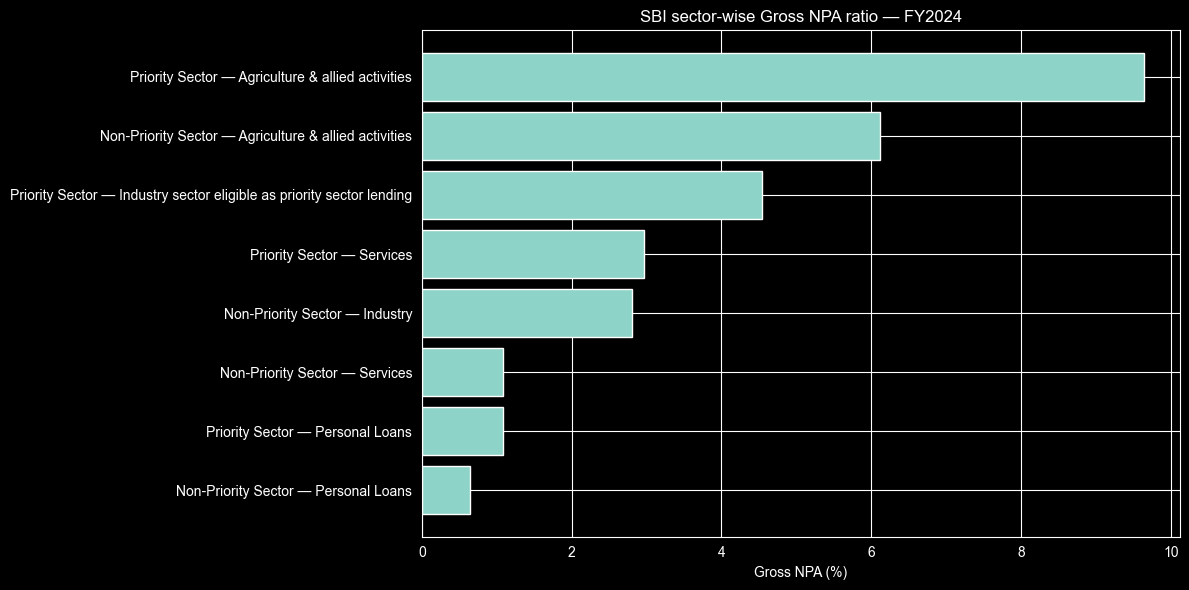

In [20]:
plot_df = detail.copy()
plot_df["label"] = plot_df["category"] + " — " + plot_df["entity"]
plot_df = plot_df.sort_values(P24)
plt.figure(figsize=(12, 6))
plt.barh(plot_df["label"], plot_df[P24])
plt.xlabel("Gross NPA (%)")
plt.title("SBI sector-wise Gross NPA ratio — FY2024")
plt.tight_layout()
plt.show()

## 07 — Retrieval chunks and vector index
Uses `sentence-transformers` + FAISS when installed. If either is missing or fails to load (common on a slow or locked-down laptop), it falls back to TF-IDF and plain NumPy, which is plenty for ~100 chunks.

In [21]:
def create_financial_chunk(row):
    return (
        f"Company: {row['company']}. Document: {row['document']}. "
        f"Category: {row['category']}. Entity: {row['entity']}. "
        f"Metric: {row['metric']}. Period: {row['period']}. "
        f"Value: {row['value']} {row['unit']}. Source page: {row['page']}. "
        f"Validation: {row['validation_status']}."
    )


financial_chunks = []
for _, row in master_financial_data.iterrows():
    financial_chunks.append({
        "chunk_id": row["record_id"], "chunk_type": "FINANCIAL_RECORD",
        "text": create_financial_chunk(row), "company": row["company"],
        "document": row["document"], "page": int(row["page"]), "table_id": row["table_id"],
        "section": row["section"], "category": row["category"], "entity": row["entity"],
        "metric": row["metric"], "period": row["period"], "unit": row["unit"],
        "value": float(row["value"]), "confidence": float(row["confidence"]),
        "validation_status": row["validation_status"],
    })
financial_chunks_df = pd.DataFrame(financial_chunks)

analysis_chunks = []
for _, row in comparison.iterrows():
    text = (
        f"SBI sector analysis for {row['category']} — {row['entity']}. "
        f"{PREVIOUS_YEAR} outstanding advances were {row[A23]} INR crore and {REPORT_YEAR} outstanding advances "
        f"were {row[A24]} INR crore. {PREVIOUS_YEAR} Gross NPA was {row[N23]} INR crore and {REPORT_YEAR} Gross NPA "
        f"was {row[N24]} INR crore. Gross NPA ratio changed from {row[P23]}% to {row[P24]}%, a change of "
        f"{row['npa_ratio_change_pp']:.2f} percentage points. Advances growth was {row['advances_growth_pct']:.2f}%. "
        f"Asset quality status: {row['asset_quality_status']}."
    )
    analysis_chunks.append({
        "chunk_id": f"INS_{len(analysis_chunks) + 1:05d}", "chunk_type": "ANALYSIS", "text": text,
        "company": COMPANY, "document": REPORT_NAME, "page": KEY_PAGE,
        "table_id": f"TEXT_PAGE_{KEY_PAGE}_SECTOR_ADVANCES", "section": "Asset Quality",
        "category": row["category"], "entity": row["entity"], "metric": "Sector Analysis",
        "period": f"{PREVIOUS_YEAR}-{REPORT_YEAR}", "unit": "Mixed", "value": np.nan,
        "confidence": 1.0, "validation_status": "CALCULATED",
    })
analysis_chunks_df = pd.DataFrame(analysis_chunks)

all_chunks = pd.concat([financial_chunks_df, analysis_chunks_df], ignore_index=True)
all_chunks.to_csv(ARTIFACT_DIR / "all_chunks.csv", index=False)
all_chunks.to_pickle(ARTIFACT_DIR / "all_chunks.pkl")
print("Chunks:", len(all_chunks))

Chunks: 85


In [22]:
class TextEmbedder:
    # sentence-transformers if available, otherwise TF-IDF. Always returns L2-normalised float32 vectors.
    def __init__(self, corpus):
        self.kind = None
        try:
            from sentence_transformers import SentenceTransformer
            self.model = SentenceTransformer(EMBEDDING_MODEL)
            self.kind = "sentence-transformers"
        except Exception as e:
            print("sentence-transformers unavailable -> using TF-IDF instead:", str(e)[:120])
            from sklearn.feature_extraction.text import TfidfVectorizer
            self.vectorizer = TfidfVectorizer(ngram_range=(1, 2), stop_words="english").fit(corpus)
            self.kind = "tfidf"

    def encode(self, texts):
        if self.kind == "sentence-transformers":
            v = self.model.encode(list(texts), normalize_embeddings=True, show_progress_bar=False)
        else:
            v = self.vectorizer.transform(list(texts)).toarray()
        v = np.asarray(v, dtype="float32")
        norms = np.linalg.norm(v, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        return v / norms


class VectorIndex:
    # FAISS if available, otherwise a NumPy dot product
    def __init__(self, matrix):
        self.matrix = np.ascontiguousarray(matrix, dtype="float32")
        self.faiss_index = None
        try:
            import faiss
            self.faiss_index = faiss.IndexFlatIP(self.matrix.shape[1])
            self.faiss_index.add(self.matrix)
            self.kind = "faiss"
        except Exception:
            self.kind = "numpy"

    def search(self, query_vec, k):
        k = max(1, min(k, len(self.matrix)))
        if self.faiss_index is not None:
            scores, idx = self.faiss_index.search(np.ascontiguousarray(query_vec, dtype="float32"), k)
            return scores[0], idx[0]
        sims = self.matrix @ query_vec[0]
        idx = np.argsort(-sims)[:k]
        return sims[idx], idx

    @property
    def ntotal(self):
        return len(self.matrix)


embedder = TextEmbedder(all_chunks["text"].tolist())
embedding_matrix = embedder.encode(all_chunks["text"].tolist())
index = VectorIndex(embedding_matrix)

np.save(ARTIFACT_DIR / "embeddings.npy", embedding_matrix)
if index.faiss_index is not None:
    import faiss
    faiss.write_index(index.faiss_index, str(ARTIFACT_DIR / "financial_index.faiss"))
print(f"Embedder: {embedder.kind} | Index: {index.kind} | Vectors: {index.ntotal} | Dimensions: {embedding_matrix.shape[1]}")

Embedder: sentence-transformers | Index: faiss | Vectors: 85 | Dimensions: 384


## 08 — Hybrid retrieval (keyword + semantic)

In [23]:
STOPWORDS = {"what", "was", "were", "the", "for", "in", "of", "to", "and", "how", "did", "is", "on", "a", "an",
             "which", "between", "from", "with", "sbi", "s"}


def tokenize(text):
    return [t for t in re.findall(r"[a-zA-Z0-9%]+", str(text).lower()) if t not in STOPWORDS and len(t) > 1]


def keyword_score(query, text):
    q, t = set(tokenize(query)), set(tokenize(text))
    return len(q & t) / len(q) if q else 0.0


def semantic_search(query, top_k=10):
    q = embedder.encode([query])
    scores, idxs = index.search(q, top_k)
    out = []
    for score, i in zip(scores, idxs):
        if i < 0:
            continue
        row = all_chunks.iloc[int(i)]
        out.append({"chunk_id": row["chunk_id"], "semantic_score": float(score),
                    "keyword_score": keyword_score(query, row["text"]),
                    "text": row["text"], "metadata": row.to_dict()})
    return out


def hybrid_search(query, top_k=TOP_K):
    candidates = semantic_search(query, max(12, top_k * 3))
    for x in candidates:
        x["hybrid_score"] = 0.70 * x["semantic_score"] + 0.30 * x["keyword_score"]
    return sorted(candidates, key=lambda x: x["hybrid_score"], reverse=True)[:top_k]


for r in hybrid_search("Which sector had the highest Gross NPA ratio in FY2024?", 3):
    print(round(r["hybrid_score"], 3), "|", r["text"][:140])

0.7 | SBI sector analysis for Non-Priority Sector — Industry. FY2023 outstanding advances were 751106.55 INR crore and FY2024 outstanding advances
0.697 | SBI sector analysis for Priority Sector — Agriculture & allied activities. FY2023 outstanding advances were 256044.09 INR crore and FY2024 o
0.696 | SBI sector analysis for Priority Sector — Services. FY2023 outstanding advances were 161450.44 INR crore and FY2024 outstanding advances wer


## 09 — Query understanding and the deterministic answer engine
This is the core. It decides what the question is asking (fact, comparison, ranking, calculation), picks the exact records, does the arithmetic in Python, and writes a complete answer with its source page. `phi3` is optional polish on top (section 11).

Fixes compared with the earlier version:
* a question mentioning **two years** is no longer reduced to one year
* **"total"** no longer triggers the comparison branch (it contained the word "to")
* **ranking excludes sub-total and total rows**, which are not sectors
* a question the data cannot answer (for example net profit) returns a clear *not available* message, never a guess

In [24]:
SUPPORTED_PERIODS = [PREVIOUS_YEAR, REPORT_YEAR]
SECTOR_METRICS = {"Outstanding Total Advances", "Gross NPAs", "Gross NPA %"}
BANK_METRICS = ["Gross NPA to Gross Advances", "Net NPA to Net Advances", "PCR excluding AUCA", "PCR including AUCA"]
LONG_INDUSTRY = "Industry sector eligible as priority sector lending"
SUBTOTAL = {"Priority Sector": "Sub-total (A)", "Non-Priority Sector": "Sub-total (B)"}
TOTAL_ENTITY = "Total (A+B)"

ENTITY_ALIASES = {
    "Agriculture & allied activities": ["agriculture & allied activities", "agriculture and allied activities",
                                        "agriculture", "agri"],
    LONG_INDUSTRY: ["industry sector eligible as priority sector lending"],
    "Industry": ["industry", "industries"],
    "Services": ["services", "service sector"],
    "Personal Loans": ["personal loans", "personal loan", "retail personal"],
    "Sub-total (A)": ["sub-total (a)", "subtotal (a)", "priority sector total", "total priority sector",
                      "priority sector sub-total"],
    "Sub-total (B)": ["sub-total (b)", "subtotal (b)", "non-priority sector total", "total non-priority sector",
                      "non-priority sector sub-total"],
    TOTAL_ENTITY: ["total (a+b)", "overall", "bank-wide", "bankwide", "whole bank", "entire bank", "total"],
}


def _has_word(text, phrase):
    return re.search(r"(?<![\w])" + re.escape(phrase) + r"(?![\w])", text) is not None


def detect_periods(question):
    out = []
    pattern = r"(?:fy\s*)?(20\d{2})\s*[-–/]\s*(\d{2,4})|fy\s*'?(20\d{2}|\d{2})\b|\b(20\d{2})\b"
    for m in re.finditer(pattern, question.lower()):
        if m.group(1):
            end = m.group(2)
            end = int(end) if len(end) == 4 else int(m.group(1)[:2] + end)
        elif m.group(3):
            y = m.group(3)
            end = int(y) if len(y) == 4 else 2000 + int(y)
        else:
            end = int(m.group(4))
        p = f"FY{end}"
        if p not in out:
            out.append(p)
    return out


def detect_metric(question):
    q = question.lower()
    ratio_words = bool(re.search(r"%|percent|percentage|ratio|rate", q))
    if re.search(r"provision coverage|\bpcr\b", q):
        return "PCR including AUCA" if "including" in q else "PCR excluding AUCA"
    if re.search(r"net\s+(npa|non[- ]performing)", q):
        return "Net NPA to Net Advances"
    if re.search(r"gross\s+(npa|non[- ]performing)", q) or re.search(r"\bnpas?\b", q):
        return "Gross NPA %" if ratio_words else "Gross NPAs"
    if "advances" in q:
        return "Outstanding Total Advances"
    return None


def detect_category(question):
    q = question.lower()
    if re.search(r"non[- ]priority", q):
        return "Non-Priority Sector"
    if "priority sector" in q or re.search(r"\bpriority\b", q):
        return "Priority Sector"
    return None


def detect_entities(question, category=None):
    q = question.lower()
    hits = []
    for canon, aliases in ENTITY_ALIASES.items():
        if any(_has_word(q, a) for a in sorted(aliases, key=len, reverse=True)):
            hits.append(canon)
    if LONG_INDUSTRY in hits and "Industry" in hits:
        hits.remove("Industry")
    specific = [h for h in hits if h != TOTAL_ENTITY]
    if specific:                                   # a named sector beats the generic word "total"
        hits = specific
    if "Industry" in hits and category == "Priority Sector":
        hits = [LONG_INDUSTRY if h == "Industry" else h for h in hits]
    elif "Industry" in hits and category is None:
        hits.append(LONG_INDUSTRY)
    return hits


def classify_query(question):
    q = question.lower()
    if re.search(r"\b(highest|lowest|top|bottom|largest|smallest|best|worst|most|least|rank|ranking)\b", q):
        return "RANKING"
    if re.search(r"\b(calculate|calculation|percentage change|growth rate|difference|how much did)\b", q):
        return "CALCULATION"
    if (re.search(r"\b(change|changed|between|compare|compared|comparison|improve|improved|deteriorat\w*|"
                  r"worsen\w*|growth|grew|increase\w*|decrease\w*|decline\w*|trend|versus|vs)\b", q)
            or len(detect_periods(q)) >= 2):
        return "COMPARISON"
    return "FACT"


def parse_financial_query(question):
    category = detect_category(question)
    q = question.lower()
    direction = "asc" if re.search(r"\b(lowest|smallest|least|bottom|best)\b", q) else "desc"
    m = re.search(r"\btop\s+(\d+)\b", q)
    return {
        "query_type": classify_query(question),
        "periods": detect_periods(question),
        "metric": detect_metric(question),
        "category": category,
        "entities": detect_entities(question, category),
        "direction": direction,
        "top_n": int(m.group(1)) if m else 3,
        "wants_improvement": bool(re.search(r"\b(improv\w*|deteriorat\w*|worsen\w*)\b", q)),
    }


tests = [
    "What was SBI's total Gross NPA percentage in FY2024?",
    "How did Agriculture & allied activities in the Priority Sector perform between FY2023 and FY2024?",
    "Which sector had the highest Gross NPA ratio in FY2024?",
    "What was the Gross NPA percentage for Industry in the Non-Priority Sector in FY2024?",
]
for t in tests:
    print(t, "\n   ->", parse_financial_query(t), "\n")

What was SBI's total Gross NPA percentage in FY2024? 
   -> {'query_type': 'FACT', 'periods': ['FY2024'], 'metric': 'Gross NPA %', 'category': None, 'entities': ['Total (A+B)'], 'direction': 'desc', 'top_n': 3, 'wants_improvement': False} 

How did Agriculture & allied activities in the Priority Sector perform between FY2023 and FY2024? 
   -> {'query_type': 'COMPARISON', 'periods': ['FY2023', 'FY2024'], 'metric': None, 'category': 'Priority Sector', 'entities': ['Agriculture & allied activities'], 'direction': 'desc', 'top_n': 3, 'wants_improvement': False} 

Which sector had the highest Gross NPA ratio in FY2024? 
   -> {'query_type': 'RANKING', 'periods': ['FY2024'], 'metric': 'Gross NPA %', 'category': None, 'entities': [], 'direction': 'desc', 'top_n': 3, 'wants_improvement': False} 

What was the Gross NPA percentage for Industry in the Non-Priority Sector in FY2024? 
   -> {'query_type': 'FACT', 'periods': ['FY2024'], 'metric': 'Gross NPA %', 'category': 'Non-Priority Sector', '

In [25]:
def fmt_value(value, unit):
    return f"{value:.2f}%" if unit == "%" else f"{value:,.2f} INR crore"


def lookup(metric, period=None, category=None, entities=None):
    df = master_financial_data[master_financial_data["metric"] == metric]
    if period:
        df = df[df["period"] == period]
    if category:
        df = df[df["category"] == category]
    if entities:
        df = df[df["entity"].isin(entities)]
    return df


def insufficient(reason):
    return {"status": "INSUFFICIENT", "text": reason, "calc": [], "records": master_financial_data.iloc[0:0], "pages": []}


NOT_AVAILABLE = ("I couldn't find sufficient evidence for that in the extracted financial data. "
                 "Currently available: sector-wise advances and Gross NPAs (Priority / Non-Priority) and the "
                 f"bank-level asset-quality ratios (Gross NPA, Net NPA, PCR) for {PREVIOUS_YEAR} and {REPORT_YEAR}, "
                 f"from PDF page {KEY_PAGE}.")


def resolve_scope(plan):
    # -> (metric, category, entities, note)
    metric, cat, ents = plan["metric"], plan["category"], list(plan["entities"])
    if metric in BANK_METRICS:
        return metric, "Asset Quality", [COMPANY], None
    if not ents and cat:
        ents = [SUBTOTAL[cat]]
    if not ents and not cat:
        if metric == "Gross NPA %":
            return "Gross NPA to Gross Advances", "Asset Quality", [COMPANY], "bank-level ratio"
        ents = [TOTAL_ENTITY]
        cat = "Total"
    return metric, cat, ents, None


def answer_fact(plan):
    if plan["metric"] is None:
        return insufficient(NOT_AVAILABLE)
    bad = [p for p in plan["periods"] if p not in SUPPORTED_PERIODS]
    if bad:
        return insufficient(f"The report data covers {PREVIOUS_YEAR} and {REPORT_YEAR} only, not {', '.join(bad)}.")
    periods = plan["periods"] or [REPORT_YEAR, PREVIOUS_YEAR]
    metric, cat, ents, note = resolve_scope(plan)
    cat_filter = None if cat in ("Total", "Asset Quality") else cat
    recs = pd.concat([lookup(metric, p, cat_filter, ents) for p in periods])
    if recs.empty:
        return insufficient(NOT_AVAILABLE)
    lines = []
    for (category, entity, metric_name), g in recs.groupby(["category", "entity", "metric"], sort=False):
        label = entity if category in ("Asset Quality", "Total") else f"{category} — {entity}"
        parts = [f"{r['period']}: {fmt_value(r['value'], r['unit'])}" for _, r in g.sort_values("period", ascending=False).iterrows()]
        lines.append(f"{label} — {metric_name} (Reported): " + "; ".join(parts))
    calc = []
    if metric == "Gross NPA to Gross Advances":      # cross-check with the sector table total
        for p in periods:
            tot = lookup("Gross NPA %", p, None, [TOTAL_ENTITY])
            rep = lookup(metric, p)
            if len(tot) and len(rep):
                same = abs(float(tot.iloc[0]["value"]) - float(rep.iloc[0]["value"])) < 0.005
                calc.append(f"Check {p}: sector table Total (A+B) ratio {tot.iloc[0]['value']:.2f}% "
                            f"{'matches' if same else 'DIFFERS from'} the asset-quality ratio {rep.iloc[0]['value']:.2f}%.")
    return {"status": "OK", "text": "\n".join(lines), "calc": calc, "records": recs,
            "pages": sorted(set(int(x) for x in recs["page"]))}


def _comparison_row(category, entity):
    r = comparison[(comparison["category"] == category) & (comparison["entity"] == entity)]
    return None if r.empty else r.iloc[0]


def _sector_lines(r, metric=None):
    lines, calc = [], []
    label = r["entity"] if r["category"] == "Total" else f"{r['category']} — {r['entity']}"
    if metric in (None, "Outstanding Total Advances"):
        lines.append(f"{label} — Outstanding Total Advances (Reported): {PREVIOUS_YEAR} {fmt_value(r[A23], 'INR crore')} -> "
                     f"{REPORT_YEAR} {fmt_value(r[A24], 'INR crore')}.")
        calc.append(f"Advances growth (Calculated): ({r[A24]:,.2f} - {r[A23]:,.2f}) / {r[A23]:,.2f} x 100 = {r['advances_growth_pct']:.2f}%")
    if metric in (None, "Gross NPAs"):
        lines.append(f"{label} — Gross NPAs (Reported): {PREVIOUS_YEAR} {fmt_value(r[N23], 'INR crore')} -> "
                     f"{REPORT_YEAR} {fmt_value(r[N24], 'INR crore')}.")
        calc.append(f"Gross NPA amount change (Calculated): ({r[N24]:,.2f} - {r[N23]:,.2f}) / {r[N23]:,.2f} x 100 = {r['npa_growth_pct']:.2f}%")
    if metric in (None, "Gross NPA %"):
        word = {"Improved": "improved", "Deteriorated": "deteriorated", "Unchanged": "was unchanged"}[r["asset_quality_status"]]
        lines.append(f"{label} — Gross NPA ratio (Reported): {PREVIOUS_YEAR} {r[P23]:.2f}% -> {REPORT_YEAR} {r[P24]:.2f}% "
                     f"(asset quality {word}).")
        calc.append(f"Gross NPA ratio change (Calculated): {r[P24]:.2f} - {r[P23]:.2f} = {r['npa_ratio_change_pp']:.2f} percentage points")
    return lines, calc


def answer_comparison(plan):
    metric = plan["metric"]
    bad = [p for p in plan["periods"] if p not in SUPPORTED_PERIODS]
    if bad:
        return insufficient(f"The report data covers {PREVIOUS_YEAR} and {REPORT_YEAR} only, not {', '.join(bad)}.")
    ents, cat = plan["entities"], plan["category"]

    # which sectors improved / deteriorated
    if plan["wants_improvement"] and not ents:
        sel = detail if cat is None else detail[detail["category"] == cat]
        improved = sel[sel["asset_quality_status"] == "Improved"].sort_values("npa_ratio_change_pp")
        worse = sel[sel["asset_quality_status"] == "Deteriorated"].sort_values("npa_ratio_change_pp", ascending=False)
        lines = ["Improved (Gross NPA ratio fell): " + "; ".join(
            f"{r['category']} — {r['entity']} ({r['npa_ratio_change_pp']:.2f} pp)" for _, r in improved.iterrows())]
        if len(worse):
            lines.append("Deteriorated (Gross NPA ratio rose): " + "; ".join(
                f"{r['category']} — {r['entity']} (+{r['npa_ratio_change_pp']:.2f} pp)" for _, r in worse.iterrows()))
        return {"status": "OK", "text": "\n".join(lines), "calc": ["Change = FY2024 ratio - FY2023 ratio, in percentage points (Calculated)"],
                "records": master_financial_data[master_financial_data["metric"] == "Gross NPA %"], "pages": [KEY_PAGE]}

    # bank-level asset quality when no sector is mentioned and the metric is not a sector amount
    if (metric in BANK_METRICS) or (metric in (None, "Gross NPA %") and not ents and not cat):
        if metric is None:
            mets = BANK_METRICS
        elif metric == "Gross NPA %":
            mets = ["Gross NPA to Gross Advances"]
        else:
            mets = [metric]
        lines, calc = [], []
        for m in mets:
            a, b = lookup(m, PREVIOUS_YEAR), lookup(m, REPORT_YEAR)
            if a.empty or b.empty:
                continue
            va, vb = float(a.iloc[0]["value"]), float(b.iloc[0]["value"])
            lines.append(f"{COMPANY} — {m} (Reported): {PREVIOUS_YEAR} {va:.2f}% -> {REPORT_YEAR} {vb:.2f}%.")
            calc.append(f"{m} change (Calculated): {vb:.2f} - {va:.2f} = {vb - va:.2f} percentage points")
        if not lines:
            return insufficient(NOT_AVAILABLE)
        recs = master_financial_data[master_financial_data["metric"].isin(mets)]
        return {"status": "OK", "text": "\n".join(lines), "calc": calc, "records": recs, "pages": [KEY_PAGE]}

    # sector comparison
    if not ents:
        ents = [SUBTOTAL[cat]] if cat else [TOTAL_ENTITY]
    lines, calc, used = [], [], []
    for e in ents:
        cats = [cat] if cat else comparison[comparison["entity"] == e]["category"].tolist()
        for c in cats:
            r = _comparison_row(c, e)
            if r is None and e == "Industry" and c == "Priority Sector":
                r = _comparison_row(c, LONG_INDUSTRY)
            if r is None:
                continue
            l, k = _sector_lines(r, metric)
            lines += l
            calc += k
            used.append((r["category"], r["entity"]))
    if not lines:
        return insufficient(NOT_AVAILABLE)
    recs = pd.concat([master_financial_data[(master_financial_data["category"] == c) & (master_financial_data["entity"] == e)]
                      for c, e in used])
    return {"status": "OK", "text": "\n".join(lines), "calc": calc, "records": recs, "pages": [KEY_PAGE]}


def answer_ranking(plan):
    metric = plan["metric"] or "Gross NPA %"
    if metric not in SECTOR_METRICS:
        return insufficient("Ranking is available for sector-wise advances, Gross NPAs and Gross NPA ratio.")
    period = (plan["periods"] or [REPORT_YEAR])[-1]
    if period not in SUPPORTED_PERIODS:
        return insufficient(f"The report data covers {PREVIOUS_YEAR} and {REPORT_YEAR} only, not {period}.")
    col = f"{period}_{metric}"
    sel = detail if plan["category"] is None else detail[detail["category"] == plan["category"]]
    asc = plan["direction"] == "asc"
    ranked = sel.sort_values(col, ascending=asc)[["category", "entity", col]].reset_index(drop=True)
    best = ranked.iloc[0][col]
    ties = ranked[np.isclose(ranked[col], best)]
    unit = "%" if metric == "Gross NPA %" else "INR crore"
    word = "lowest" if asc else "highest"
    if len(ties) > 1:
        head = f"Joint {word} {metric} in {period} ({fmt_value(best, unit)}): " + "; ".join(
            f"{r['category']} — {r['entity']}" for _, r in ties.iterrows()) + "."
    else:
        r0 = ranked.iloc[0]
        head = f"{r0['category']} — {r0['entity']} had the {word} {metric} in {period}: {fmt_value(best, unit)} (Reported)."
    rest = [f"{i + 1}. {r['category']} — {r['entity']}: {fmt_value(r[col], unit)}"
            for i, r in ranked.head(max(plan["top_n"], len(ties))).iterrows()]
    recs = master_financial_data[(master_financial_data["metric"] == metric) & (master_financial_data["period"] == period)
                                 & (~master_financial_data["entity"].str.startswith(AGGREGATE_PREFIXES))]
    return {"status": "OK", "text": head + "\nRanking (sub-totals and totals excluded):\n" + "\n".join(rest),
            "calc": [f"Ranked by {metric}, {period}, sectors only (Calculated ordering of reported values)"],
            "records": recs, "pages": [KEY_PAGE]}


def answer_query(question):
    plan = parse_financial_query(question)
    qtype = plan["query_type"]
    if qtype == "RANKING":
        res = answer_ranking(plan)
    elif qtype in ("COMPARISON", "CALCULATION"):
        res = answer_comparison(plan)
    else:
        res = answer_fact(plan)
    res["plan"] = plan
    return res


for q in tests + ["What was SBI's net profit in FY2024?"]:
    r = answer_query(q)
    print("Q:", q, "\n[", r["status"], "] pages", r["pages"], "\n" + r["text"])
    for c in r["calc"]:
        print("   calc:", c)
    print()

Q: What was SBI's total Gross NPA percentage in FY2024? 
[ OK ] pages [204] 
Total (A+B) — Gross NPA % (Reported): FY2024: 2.24%

Q: How did Agriculture & allied activities in the Priority Sector perform between FY2023 and FY2024? 
[ OK ] pages [204] 
Priority Sector — Agriculture & allied activities — Outstanding Total Advances (Reported): FY2023 256,044.09 INR crore -> FY2024 302,705.43 INR crore.
Priority Sector — Agriculture & allied activities — Gross NPAs (Reported): FY2023 29,587.72 INR crore -> FY2024 29,169.55 INR crore.
Priority Sector — Agriculture & allied activities — Gross NPA ratio (Reported): FY2023 11.56% -> FY2024 9.64% (asset quality improved).
   calc: Advances growth (Calculated): (302,705.43 - 256,044.09) / 256,044.09 x 100 = 18.22%
   calc: Gross NPA amount change (Calculated): (29,169.55 - 29,587.72) / 29,587.72 x 100 = -1.41%
   calc: Gross NPA ratio change (Calculated): 9.64 - 11.56 = -1.92 percentage points

Q: Which sector had the highest Gross NPA ratio in 

## 10 — Grounded RAG context
Compact on purpose: `phi3` has a small context window, so it gets the deterministic answer plus at most 3 supporting chunks that are not already in the answer.

In [26]:
def build_rag_context(result, semantic_results, max_chars=380, max_sources=3):
    parts = []
    used_pages = set(result["pages"])
    seen_text = set()
    for r in semantic_results:
        meta = r["metadata"]
        key = (meta["entity"], meta["metric"], meta["period"])
        if key in seen_text:
            continue
        seen_text.add(key)
        parts.append(
            f"SOURCE {len(parts) + 1} (PDF page {meta['page']}, {meta['chunk_type']}): "
            f"{r['text'][:max_chars]}")
        if len(parts) >= max_sources:
            break
    return "\n".join(parts)

## 11 — phi3 answer polishing with a number guard
`phi3` is given the finished answer and asked only to word it clearly. Then the **number guard** checks every number in phi3's reply against the numbers Python produced. If phi3 introduced a number that is not in the deterministic answer or the evidence, its reply is rejected and the deterministic answer is returned. A small local model can therefore never put a wrong figure in front of you.

In [27]:
def numbers_in(text):
    text = re.sub(r"(?i)\bfy\s*\d{2,4}(?:\s*[-–]\s*\d{2,4})?|\b20\d{2}\s*[-–]\s*\d{2,4}|\bpages?\s*\d+|\b(?:19|20)\d{2}\b", " ", str(text))
    out = []
    for m in re.findall(r"\d[\d,]*\.?\d*", text):
        v = clean_number(m.rstrip(".,"))
        if v is not None:
            out.append(abs(v))
    return out


def number_guard(llm_text, allowed_text):
    allowed = np.array(sorted(set(numbers_in(allowed_text)))) if allowed_text else np.array([])
    bad = []
    for v in numbers_in(llm_text):
        if v < 10 and float(v).is_integer():          # '2 years', list numbers
            continue
        if allowed.size == 0 or np.min(np.abs(allowed - v)) > max(0.006, 1e-4 * v):
            bad.append(v)
    return sorted(set(bad))


SYSTEM_PROMPT = ("You are a careful financial research assistant. Use only the supplied answer and evidence. "
                 "Never invent or change a number. Keep every figure exactly as given.")


def create_financial_prompt(question, result, context):
    calc = "\n".join(result["calc"]) if result["calc"] else "(none)"
    return (
        f"Question: {question}\n\n"
        f"VERIFIED ANSWER (numbers are final):\n{result['text']}\n\n"
        f"CALCULATIONS (done by Python):\n{calc}\n\n"
        f"SUPPORTING EVIDENCE:\n{context}\n\n"
        "Task: Write a short, clear answer to the question (at most 4 sentences) using ONLY the verified answer. "
        "Copy numbers exactly. Say 'Reported' for numbers taken from the report and 'Calculated' for derived numbers. "
        "End with a line: Source: PDF page <number>. Do not add anything else."
    )


def ask_phi3(prompt, temperature=0.0):
    if not (USE_LLM and OLLAMA_OK):
        return None
    try:
        chat = (_ollama_client or ollama).chat
        r = chat(model=OLLAMA_MODEL,
                 messages=[{"role": "system", "content": SYSTEM_PROMPT}, {"role": "user", "content": prompt}],
                 options={"temperature": temperature, "num_ctx": 4096, "num_predict": 350})
        return r["message"]["content"].strip()
    except Exception as e:
        print("phi3 call failed:", str(e)[:160])
        return None


def ask_financial_ai(question, top_k=TOP_K, use_llm=None):
    use_llm = USE_LLM if use_llm is None else use_llm
    result = answer_query(question)
    semantic = hybrid_search(question, top_k)
    context = build_rag_context(result, semantic)
    pages = result["pages"]
    source_line = f"Source: PDF page {', '.join(str(p) for p in pages)} ({REPORT_NAME})" if pages else ""

    deterministic = result["text"] + ("\n" + "\n".join(result["calc"]) if result["calc"] else "") + (f"\n{source_line}" if source_line else "")
    final, answer_source, note, prompt = deterministic, "deterministic", "", None

    if use_llm and result["status"] == "OK":
        prompt = create_financial_prompt(question, result, context)
        llm_text = ask_phi3(prompt)
        if llm_text is None:
            note = "phi3 unavailable -> deterministic answer"
        else:
            allowed = result["text"] + "\n" + "\n".join(result["calc"]) + "\n" + context
            bad = number_guard(llm_text, allowed)
            if bad:
                note = f"phi3 reply rejected (numbers not in the evidence: {bad}) -> deterministic answer"
            else:
                final = llm_text if source_line.split(" (")[0] in llm_text else llm_text + "\n" + source_line
                answer_source = "phi3 (number-checked)"
    return {"question": question, "answer": final, "answer_source": answer_source, "note": note,
            "status": result["status"], "deterministic_answer": deterministic, "pages": pages,
            "plan": result["plan"], "calc": result["calc"], "records": result["records"],
            "semantic_results": semantic, "rag_context": context, "prompt": prompt}


def show_answer(r):
    print("QUESTION:", r["question"])
    print(f"ANSWER  [{r['answer_source']}]:")
    print(r["answer"])
    if r["note"]:
        print("NOTE:", r["note"])

## 12 — End-to-end tests

In [42]:
questions = [
    "What was the Gross NPA percentage for Agriculture & allied activities in the Priority Sector in FY2024?",
    "What was SBI's total Gross NPA percentage in FY2024?",
    "How did Agriculture & allied activities in the Priority Sector perform between FY2023 and FY2024?",
    "Which sector had the highest Gross NPA ratio in FY2024?",
    "What was SBI's net profit in FY2024?",
    "What were SBI's total assets as of March 31, 2024?"
]
for q in questions:
    banner(q)
    show_answer(ask_financial_ai(q))

QUESTION: Which sector had the highest Gross NPA ratio in FY2024?
ANSWER  [phi3 (number-checked)]:
The highest Gross NPA ratio in FY2024 was in the Priority Sector — Agriculture & allied activities, with a reported ratio of 9.64%. This is calculated based on the outstanding advances and Gross NPA figures provided in the sources. The Priority Sector — Industry sector eligible as priority sector lending had a lower ratio of 4.54%. Source: PDF page 204.

What was SBI's net profit in FY2024?
QUESTION: What was SBI's net profit in FY2024?
ANSWER  [deterministic]:
I couldn't find sufficient evidence for that in the extracted financial data. Currently available: sector-wise advances and Gross NPAs (Priority / Non-Priority) and the bank-level asset-quality ratios (Gross NPA, Net NPA, PCR) for FY2023 and FY2024, from PDF page 204.

What were SBI's total assets as of March 31, 2024?
QUESTION: What were SBI's total assets as of March 31, 2024?
ANSWER  [deterministic]:
I couldn't find sufficient e

## 13 — Evaluation
Every expected value below comes from the report itself (page 204) or is calculated from those values. Three scores:
* **Answer correct**: the expected number appears in the final answer
* **Page correct**: the answer cites PDF page 204
* **Refusal correct**: for a question the data cannot answer, the system says so instead of guessing

In [29]:
def _calc_growth(entity, category):
    r = _comparison_row(category, entity)
    return round(float(r["advances_growth_pct"]), 2)


evaluation_questions = [
    {"question": "What was the Gross NPA percentage for Agriculture & allied activities in the Priority Sector in FY2024?", "expected_value": 9.64, "expected_page": 204},
    {"question": "What was the Gross NPA percentage for Industry in the Non-Priority Sector in FY2024?", "expected_value": 2.81, "expected_page": 204},
    {"question": "What was SBI's total Gross NPA percentage in FY2024?", "expected_value": 2.24, "expected_page": 204},
    {"question": "What was the Gross NPA percentage for Services in the Non-Priority Sector in FY2024?", "expected_value": 1.08, "expected_page": 204},
    {"question": "What was the Gross NPA percentage for Personal Loans in the Priority Sector in FY2024?", "expected_value": 1.08, "expected_page": 204},
    {"question": "What was SBI's Net NPA ratio in FY2024?", "expected_value": 0.57, "expected_page": 204},
    {"question": "What was the provision coverage ratio excluding AUCA in FY2023?", "expected_value": 76.39, "expected_page": 204},
    {"question": "What were SBI's total advances in FY2024?", "expected_value": 3767534.51, "expected_page": 204},
    {"question": "Which sector had the highest Gross NPA ratio in FY2024?", "expected_value": 9.64, "expected_page": 204},
    {"question": "How did the Gross NPA ratio of Agriculture & allied activities in the Priority Sector change between FY2023 and FY2024?", "expected_value": 1.92, "expected_page": 204},
    {"question": "What was the growth in total advances between FY2023 and FY2024?", "expected_value": _calc_growth(TOTAL_ENTITY, "Total"), "expected_page": 204},
    {"question": "What was SBI's net profit in FY2024?", "expected_value": None, "expected_page": None, "unanswerable": True},
    {"question": "What was the Gross NPA percentage for Services in FY2020?", "expected_value": None, "expected_page": None, "unanswerable": True},
]


def value_in_text(value, text):
    return any(abs(v - abs(value)) <= max(0.006, 1e-4 * abs(value)) for v in numbers_in(text))


def evaluate_item(item, use_llm=False):
    r = ask_financial_ai(item["question"], use_llm=use_llm)
    if item.get("unanswerable"):
        return {"question": item["question"], "kind": "refusal", "correct": r["status"] == "INSUFFICIENT",
                "page_ok": None, "answer_source": r["answer_source"]}
    return {"question": item["question"], "kind": "answer",
            "correct": value_in_text(item["expected_value"], r["answer"]),
            "page_ok": item["expected_page"] in r["pages"], "answer_source": r["answer_source"]}


eval_df = pd.DataFrame([evaluate_item(x) for x in evaluation_questions])
display(eval_df)
ans = eval_df[eval_df["kind"] == "answer"]
ref = eval_df[eval_df["kind"] == "refusal"]
print(f"Answer correct : {ans['correct'].mean() * 100:.1f}%  ({int(ans['correct'].sum())}/{len(ans)})")
print(f"Page correct   : {ans['page_ok'].mean() * 100:.1f}%")
print(f"Refusal correct: {ref['correct'].mean() * 100:.1f}%  ({int(ref['correct'].sum())}/{len(ref)})")

Answer correct : 100.0%  (11/11)
Page correct   : 100.0%
Refusal correct: 100.0%  (2/2)


In [30]:
# Optional: score the phi3 layer (slow). Set RUN_LLM_EVALUATION = True in cell 00 to run it.
if RUN_LLM_EVALUATION and OLLAMA_OK:
    llm_rows = [evaluate_item(x, use_llm=True) for x in evaluation_questions]
    llm_eval_df = pd.DataFrame(llm_rows)
    display(llm_eval_df)
    a = llm_eval_df[llm_eval_df["kind"] == "answer"]
    print(f"phi3 answer correct: {a['correct'].mean() * 100:.1f}%")
    print("Answers served by phi3:", int(llm_eval_df['answer_source'].str.startswith('phi3').sum()), "of", len(llm_eval_df))
else:
    print("LLM evaluation skipped (RUN_LLM_EVALUATION is False or Ollama is not running).")

LLM evaluation skipped (RUN_LLM_EVALUATION is False or Ollama is not running).


## 14 — Artifact manifest

In [31]:
manifest = {
    "project": PROJECT_NAME, "company": COMPANY, "report": REPORT_NAME,
    "llm": OLLAMA_MODEL if OLLAMA_OK else "not used",
    "embedding_model": EMBEDDING_MODEL if embedder.kind == "sentence-transformers" else "tfidf (fallback)",
    "vector_index": index.kind,
    "source_pdf": str(SOURCE_PDF), "pages": int(N_PAGES),
    "raw_tables": int(len(raw_tables)), "normalized_tables": int(len(normalized_tables)),
    "financial_records": int(len(master_financial_data)), "retrieval_chunks": int(len(all_chunks)),
    "vectors": int(index.ntotal),
    "sector_table_status": SECTOR_STATUS,
    "validation_pass_rate": float((validation_df["status"] == "PASS").mean()),
    "evaluation_answer_accuracy": float(ans["correct"].mean()),
    "evaluation_refusal_accuracy": float(ref["correct"].mean()),
}
(ARTIFACT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
print(json.dumps(manifest, indent=2))

{
  "project": "SBI Financial Report Intelligence System",
  "company": "State Bank of India",
  "report": "Annual Report 2023-24",
  "llm": "phi3",
  "embedding_model": "all-MiniLM-L6-v2",
  "vector_index": "faiss",
  "source_pdf": "C:\\Users\\Ansh\\Desktop\\SBI LLM\\Data\\AR_24037_SBIN_2023_2024_27052024232418.pdf",
  "pages": 486,
  "raw_tables": 478,
  "normalized_tables": 478,
  "financial_records": 74,
  "retrieval_chunks": 85,
  "vectors": 85,
  "sector_table_status": "REPORT_VALIDATED",
  "validation_pass_rate": 1.0,
  "evaluation_answer_accuracy": 1.0,
  "evaluation_refusal_accuracy": 1.0
}


## Status and known limits

**Working and checked**
- [x] Runs in plain Jupyter (no Colab, no shell scripts); slow steps are cached
- [x] Page text, images, tables extracted; financial table classification
- [x] Asset-quality ratios and the sector-wise advances table parsed from page 204 and checked against hand-verified values
- [x] Deterministic fact, comparison, ranking and calculation engine with source pages
- [x] Hybrid retrieval (keyword + semantic) with automatic fallback to TF-IDF / NumPy
- [x] `phi3` polish with a number guard; automatic fallback to the deterministic answer
- [x] Evaluation set with answer, page and refusal scoring

**Not covered yet (the system says so instead of guessing)**
- Anything outside page 204: net profit, deposits, total assets, ROA/ROE, capital ratios, and so on. Those need their own table parsers, added the same way as 05B–05D.
- Other years and other banks (the structure supports it; the data does not exist yet).
- Reading values from charts.

In [41]:
questions = [
    "What were SBI's total assets as of March 31, 2024?"
]
for r in questions:
    banner(r)
    show_answer(ask_financial_ai(r))


What were SBI's total assets as of March 31, 2024?
QUESTION: What were SBI's total assets as of March 31, 2024?
ANSWER  [deterministic]:
I couldn't find sufficient evidence for that in the extracted financial data. Currently available: sector-wise advances and Gross NPAs (Priority / Non-Priority) and the bank-level asset-quality ratios (Gross NPA, Net NPA, PCR) for FY2023 and FY2024, from PDF page 204.
